# Assignment 1 | EDA 2: Post-Cleaning Analysis
Analysis on silver (cleaned) data joined with target labels.

**Structure:**
1. Post-cleaning validation (confirm silver data is clean)
2. Label definition experiment (compare dpd/mob combos)
3. Distributions (cleaned numeric + categorical features)
4. Clickstream missingness analysis
5. Bivariate analysis (features vs label)
6. Correlation matrix (redundancy check)
7. Feature selection summary for gold layer

In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pyspark
import pyspark.sql.functions as F
from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_gold_table

pd.set_option('display.max_columns', None)

## Config

In [39]:
spark = pyspark.sql.SparkSession.builder \
    .appName("eda2") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

In [40]:
silver_loan_directory = "datamart/silver/loan/"
silver_attributes_directory = "datamart/silver/attributes/"
silver_financials_directory = "datamart/silver/financials/"
silver_clickstream_directory = "datamart/silver/clickstream/"

def load_all_parquet(directory):
    files = glob.glob(os.path.join(directory, '*.parquet'))
    df = spark.read.parquet(*files)
    return df.toPandas()

df_loan = load_all_parquet(silver_loan_directory)
df_attr = load_all_parquet(silver_attributes_directory)
df_fin = load_all_parquet(silver_financials_directory)
df_click = load_all_parquet(silver_clickstream_directory)

for name, df in [('Loan', df_loan), ('Attributes', df_attr), ('Financials', df_fin), ('Clickstream', df_click)]:
    print(f"{name}: {df.shape}")

Loan: (137500, 15)
Attributes: (12500, 4)
Financials: (12500, 22)
Clickstream: (215376, 22)


## 1. Post-Cleaning Validation
Confirm silver data is clean after silver layer processing.

In [41]:
print("=== Silver Attributes ===")
print(f"Shape: {df_attr.shape}")
print(f"\nDtypes:\n{df_attr.dtypes}")
print(f"\nNull counts:\n{df_attr.isnull().sum()}")
print(f"\nAge range: {df_attr['Age'].min()} to {df_attr['Age'].max()}")
print(f"Age nulls: {df_attr['Age'].isnull().sum()} ({df_attr['Age'].isnull().mean()*100:.1f}%)")
print(f"\nOccupation values:\n{df_attr['Occupation'].value_counts(dropna=False)}")
print(f"\nConfirm no PII columns: {[c for c in df_attr.columns if c in ['Name', 'SSN']]}")

=== Silver Attributes ===
Shape: (12500, 4)

Dtypes:
Customer_ID       object
Age              float64
Occupation        object
snapshot_date     object
dtype: object

Null counts:
Customer_ID        0
Age              988
Occupation       880
snapshot_date      0
dtype: int64

Age range: 18.0 to 56.0
Age nulls: 988 (7.9%)

Occupation values:
Occupation
None             880
Lawyer           828
Architect        795
Engineer         793
Accountant       791
Scientist        789
Teacher          782
Developer        780
Media_Manager    780
Mechanic         780
Entrepreneur     776
Journalist       761
Doctor           760
Musician         741
Manager          736
Writer           728
Name: count, dtype: int64

Confirm no PII columns: []


In [42]:
print("=== Silver Financials ===")
print(f"Shape: {df_fin.shape}")
print(f"\nDtypes:\n{df_fin.dtypes}")
print(f"\nNull counts:\n{df_fin.isnull().sum()}")

dirty_cols = ['Annual_Income', 'Outstanding_Debt', 'Monthly_Balance']
for c in dirty_cols:
    non_numeric = df_fin[c].apply(lambda x: isinstance(x, str))
    print(f"\n{c}: string values remaining = {non_numeric.sum()}")

print(f"\nNum_Bank_Accounts range: {df_fin['Num_Bank_Accounts'].min()} to {df_fin['Num_Bank_Accounts'].max()}")
print(f"Num_Credit_Card range: {df_fin['Num_Credit_Card'].min()} to {df_fin['Num_Credit_Card'].max()}")
print(f"Interest_Rate range: {df_fin['Interest_Rate'].min()} to {df_fin['Interest_Rate'].max()}")
print(f"Num_of_Loan range: {df_fin['Num_of_Loan'].min()} to {df_fin['Num_of_Loan'].max()}")

print(f"\nCredit_Mix values:\n{df_fin['Credit_Mix'].value_counts(dropna=False)}")
print(f"\nPayment_of_Min_Amount values:\n{df_fin['Payment_of_Min_Amount'].value_counts(dropna=False)}")
print(f"\nspending_level values:\n{df_fin['spending_level'].value_counts(dropna=False)}")
print(f"\npayment_value_level values:\n{df_fin['payment_value_level'].value_counts(dropna=False)}")
print(f"\nCredit_History_Age range: {df_fin['Credit_History_Age'].min()} to {df_fin['Credit_History_Age'].max()}")

=== Silver Financials ===
Shape: (12500, 22)

Dtypes:
Customer_ID                  object
Annual_Income               float32
Monthly_Inhand_Salary       float32
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate               float64
Num_of_Loan                 float64
Delay_from_due_date           int32
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float32
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float32
Credit_Utilization_Ratio    float32
Credit_History_Age            int32
Payment_of_Min_Amount        object
Total_EMI_per_month         float32
Amount_invested_monthly     float32
Monthly_Balance             float32
snapshot_date                object
spending_level              float64
payment_value_level         float64
dtype: object

Null counts:
Customer_ID                    0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts          

In [43]:
print("=== Silver Loan ===")
print(f"Shape: {df_loan.shape}")
print(f"\nDtypes:\n{df_loan.dtypes}")
print(f"\nNull counts:\n{df_loan.isnull().sum()}")
print(f"\nNew columns: mob={('mob' in df_loan.columns)}, dpd={('dpd' in df_loan.columns)}, installments_missed={('installments_missed' in df_loan.columns)}")
print(f"DPD range: {df_loan['dpd'].min()} to {df_loan['dpd'].max()}")

=== Silver Loan ===
Shape: (137500, 15)

Dtypes:
loan_id                 object
Customer_ID             object
loan_start_date         object
tenure                   int32
installment_num          int32
loan_amt               float32
due_amt                float32
paid_amt               float32
overdue_amt            float32
balance                float32
snapshot_date           object
mob                      int32
installments_missed      int32
first_missed_date       object
dpd                      int32
dtype: object

Null counts:
loan_id                     0
Customer_ID                 0
loan_start_date             0
tenure                      0
installment_num             0
loan_amt                    0
due_amt                     0
paid_amt                    0
overdue_amt                 0
balance                     0
snapshot_date               0
mob                         0
installments_missed         0
first_missed_date      108624
dpd                         0
dtype: i

In [44]:
print("=== Silver Clickstream ===")
print(f"Shape: {df_click.shape}")
print(f"Total nulls: {df_click.isnull().sum().sum()}")
fe_cols = [f'fe_{i}' for i in range(1, 21)]
print(f"\nFeature ranges:")
for c in fe_cols:
    print(f"  {c}: {df_click[c].min()} to {df_click[c].max()}")

=== Silver Clickstream ===
Shape: (215376, 22)
Total nulls: 0

Feature ranges:
  fe_1: -378 to 541
  fe_2: -356 to 560
  fe_3: -399 to 583
  fe_4: -307 to 562
  fe_5: -343 to 570
  fe_6: -321 to 565
  fe_7: -368 to 537
  fe_8: -361 to 573
  fe_9: -328 to 577
  fe_10: -317 to 537
  fe_11: -375 to 613
  fe_12: -344 to 550
  fe_13: -355 to 530
  fe_14: -394 to 583
  fe_15: -351 to 597
  fe_16: -342 to 554
  fe_17: -329 to 516
  fe_18: -344 to 551
  fe_19: -401 to 560
  fe_20: -354 to 547


In [45]:
print("=== Null Rate Summary ===\n")
for name, df in [('Attributes', df_attr), ('Financials', df_fin)]:
    null_pct = (df.isnull().sum() / len(df) * 100).round(1)
    null_pct = null_pct[null_pct > 0]
    if len(null_pct) > 0:
        print(f"--- {name} ---")
        print(null_pct.to_string())
        print()
    else:
        print(f"--- {name} --- no nulls\n")

=== Null Rate Summary ===

--- Attributes ---
Age           7.9
Occupation    7.0

--- Financials ---
Num_Bank_Accounts           1.4
Num_Credit_Card             2.4
Interest_Rate               2.2
Num_of_Loan                 4.5
Num_of_Delayed_Payment      0.7
Changed_Credit_Limit        2.0
Num_Credit_Inquiries        1.6
Credit_Mix                 20.9
Payment_of_Min_Amount      11.5
Total_EMI_per_month         5.0
Amount_invested_monthly     4.5
spending_level              8.0
payment_value_level         8.0



### Section 1 Summary: Post-Cleaning Validation

Silver layer cleaning confirmed across all four tables:

- **Attributes** (12,500 rows): Age range valid (18-56), PII columns (Name, SSN) removed, placeholder occupations replaced with null. Null rates: Age 7.9%, Occupation 7.0%.
- **Financials** (12,500 rows): Trailing underscores stripped, placeholder values replaced with null, impossible values nulled, Credit_History_Age converted to months, Payment_Behaviour split into two ordinal columns, Type_of_Loan dropped. Highest null rate: Credit_Mix 20.9%.
- **Loan** (137,500 rows): Schema enforced, derived columns added (mob, dpd, installments_missed). DPD range 0-306.
- **Clickstream** (215,376 rows): Zero nulls, all 20 features present with expected numeric ranges.

**Design decision:** No imputation at silver layer. Nulls are preserved as NaN for tree-based models to handle natively. This avoids introducing bias from mean/median imputation on features with up to 20.9% missingness.

## 2. Label Definition Experiment
Compare DPD thresholds and MOB windows: 30dpd_6mob, 30dpd_10mob, 60dpd_6mob, 60dpd_10mob.

In [46]:
combos = [(30, 6), (30, 10), (60, 6), (60, 10)]
label_results = {}

files = glob.glob(os.path.join(silver_loan_directory, '*.parquet'))
df_silver_loan = spark.read.parquet(*files)

for dpd_thresh, mob_window in combos:
    label_name = f"{dpd_thresh}dpd_{mob_window}mob"
    
    df_temp = df_silver_loan.filter(col("mob") == mob_window)
    df_temp = df_temp.withColumn("label", F.when(col("dpd") >= dpd_thresh, 1).otherwise(0))
    
    pdf = df_temp.select("Customer_ID", "loan_id", "label").toPandas()
    pdf = pdf.drop_duplicates(subset=['loan_id'])
    
    bad_rate = pdf['label'].mean()
    n_bad = pdf['label'].sum()
    n_total = len(pdf)
    
    label_results[label_name] = {
        'dpd': dpd_thresh, 'mob': mob_window,
        'n_total': n_total, 'n_bad': int(n_bad),
        'n_good': n_total - int(n_bad),
        'bad_rate_pct': round(bad_rate * 100, 2),
    }
    print(f"{label_name}: {n_total} loans, {int(n_bad)} bads, bad rate = {bad_rate*100:.1f}%")

pd.DataFrame(label_results).T

30dpd_6mob: 12500 loans, 3602 bads, bad rate = 28.8%
30dpd_10mob: 12500 loans, 3602 bads, bad rate = 28.8%
60dpd_6mob: 12500 loans, 3553 bads, bad rate = 28.4%
60dpd_10mob: 12500 loans, 3602 bads, bad rate = 28.8%


,dpd,mob,n_total,n_bad,n_good,bad_rate_pct
30dpd_6mob,30.0,6.0,12500.0,3602.0,8898.0,28.82
30dpd_10mob,30.0,10.0,12500.0,3602.0,8898.0,28.82
60dpd_6mob,60.0,6.0,12500.0,3553.0,8947.0,28.42
60dpd_10mob,60.0,10.0,12500.0,3602.0,8898.0,28.82


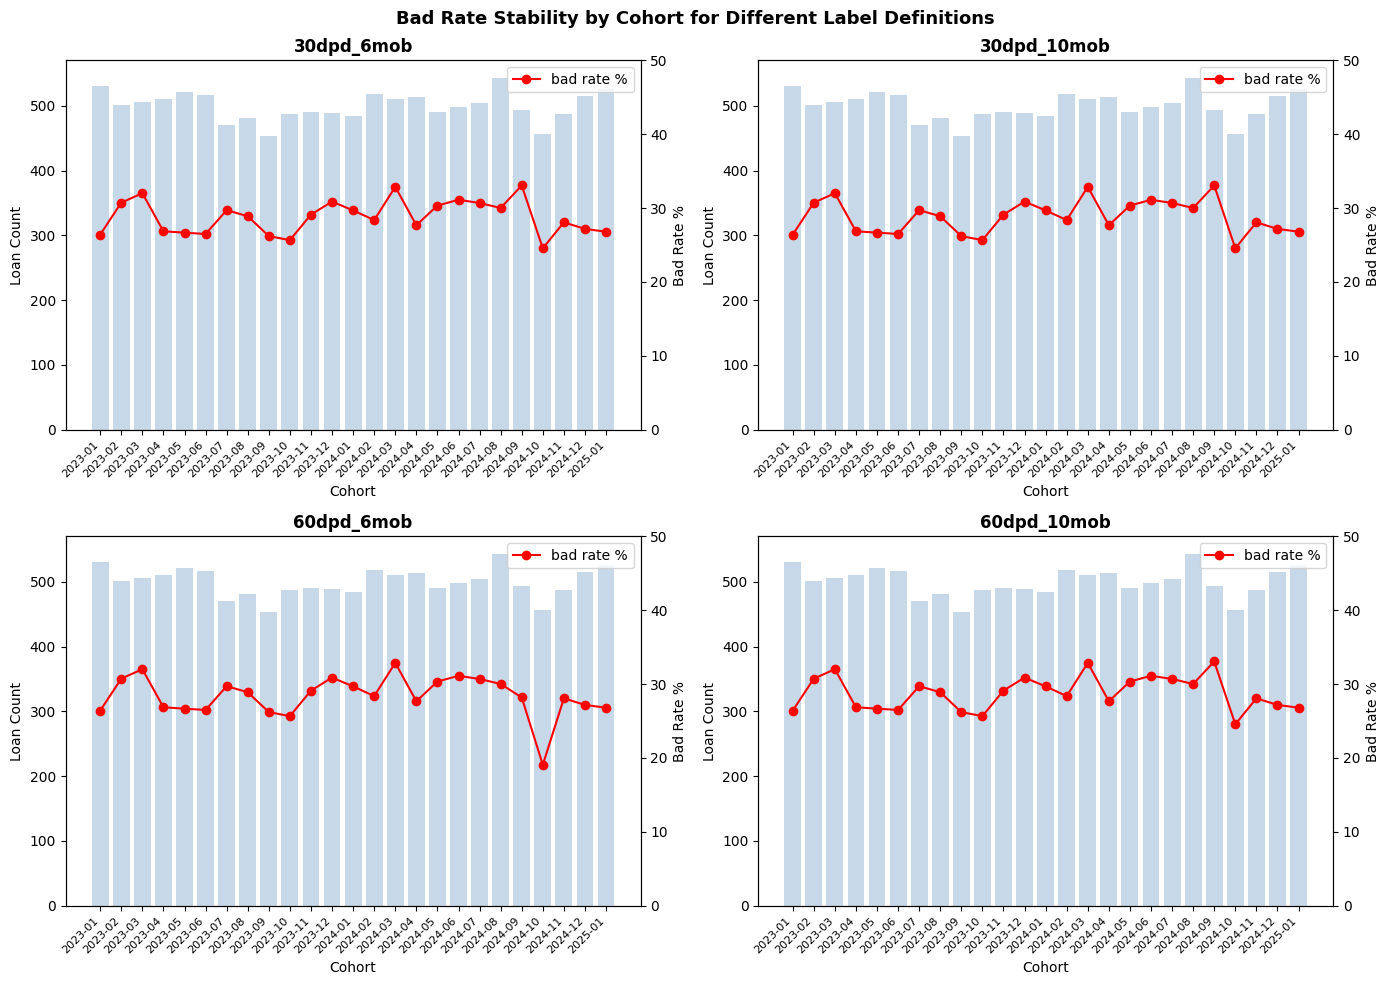

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (dpd_thresh, mob_window) in enumerate(combos):
    label_name = f"{dpd_thresh}dpd_{mob_window}mob"
    
    df_temp = df_silver_loan.filter(col("mob") == mob_window)
    df_temp = df_temp.withColumn("label", F.when(col("dpd") >= dpd_thresh, 1).otherwise(0))
    
    pdf = df_temp.select("loan_id", "Customer_ID", "loan_start_date", "label").toPandas()
    pdf = pdf.drop_duplicates(subset=['loan_id'])
    pdf['cohort'] = pd.to_datetime(pdf['loan_start_date']).dt.to_period('M')
    
    cohort_stats = pdf.groupby('cohort')['label'].agg(['mean', 'count'])
    cohort_stats = cohort_stats[cohort_stats['count'] >= 30]
    
    ax = axes[idx]
    ax.bar(range(len(cohort_stats)), cohort_stats['count'], alpha=0.3, color='steelblue', label='loan count')
    ax2 = ax.twinx()
    ax2.plot(range(len(cohort_stats)), cohort_stats['mean'] * 100, 'ro-', label='bad rate %')
    
    ax.set_title(label_name, fontweight='bold')
    ax.set_xlabel('Cohort')
    ax.set_ylabel('Loan Count')
    ax2.set_ylabel('Bad Rate %')
    ax2.set_ylim(0, 50)
    ax.set_xticks(range(len(cohort_stats)))
    ax.set_xticklabels([str(p) for p in cohort_stats.index], rotation=45, ha='right', fontsize=8)
    ax2.legend(loc='upper right')

plt.suptitle('Bad Rate Stability by Cohort for Different Label Definitions', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [48]:
# Cohort stability table
combos = [(30, 6), (30, 10), (60, 6), (60, 10)]
files = glob.glob(os.path.join(silver_loan_directory, '*.parquet'))
df_silver_loan = spark.read.parquet(*files)

rows = []
for dpd_thresh, mob_window in combos:
    label_name = f"{dpd_thresh}dpd_{mob_window}mob"
    df_temp = df_silver_loan.filter(col("mob") == mob_window)
    df_temp = df_temp.withColumn("label", F.when(col("dpd") >= dpd_thresh, 1).otherwise(0))
    pdf = df_temp.select("loan_id", "loan_start_date", "label").toPandas()
    pdf = pdf.drop_duplicates(subset=['loan_id'])
    pdf['cohort'] = pd.to_datetime(pdf['loan_start_date']).dt.to_period('M')
    
    cohort_stats = pdf.groupby('cohort')['label'].agg(['mean', 'count']).reset_index()
    cohort_stats['bad_rate_pct'] = (cohort_stats['mean'] * 100).round(2)
    cohort_stats['label_def'] = label_name
    rows.append(cohort_stats[['cohort', 'label_def', 'count', 'bad_rate_pct']])

cohort_table = pd.concat(rows, ignore_index=True)

pivot = cohort_table.pivot_table(index='cohort', columns='label_def', values='bad_rate_pct')
pivot.columns.name = None
print(pivot.to_string())
print(f"\nBad rate range across all cohorts: {cohort_table['bad_rate_pct'].min():.1f}% - {cohort_table['bad_rate_pct'].max():.1f}%")
print(f"Std dev (30dpd_6mob): {cohort_table.loc[cohort_table['label_def']=='30dpd_6mob','bad_rate_pct'].std():.2f}%")

         30dpd_10mob  30dpd_6mob  60dpd_10mob  60dpd_6mob
cohort                                                   
2023-01        26.42       26.42        26.42       26.42
2023-02        30.74       30.74        30.74       30.74
2023-03        32.02       32.02        32.02       32.02
2023-04        26.86       26.86        26.86       26.86
2023-05        26.68       26.68        26.68       26.68
2023-06        26.50       26.50        26.50       26.50
2023-07        29.72       29.72        29.72       29.72
2023-08        28.90       28.90        28.90       28.90
2023-09        26.21       26.21        26.21       26.21
2023-10        25.67       25.67        25.67       25.67
2023-11        29.12       29.12        29.12       29.12
2023-12        30.88       30.88        30.88       30.88
2024-01        29.69       29.69        29.69       29.69
2024-02        28.38       28.38        28.38       28.38
2024-03        32.88       32.88        32.88       32.88
2024-04       

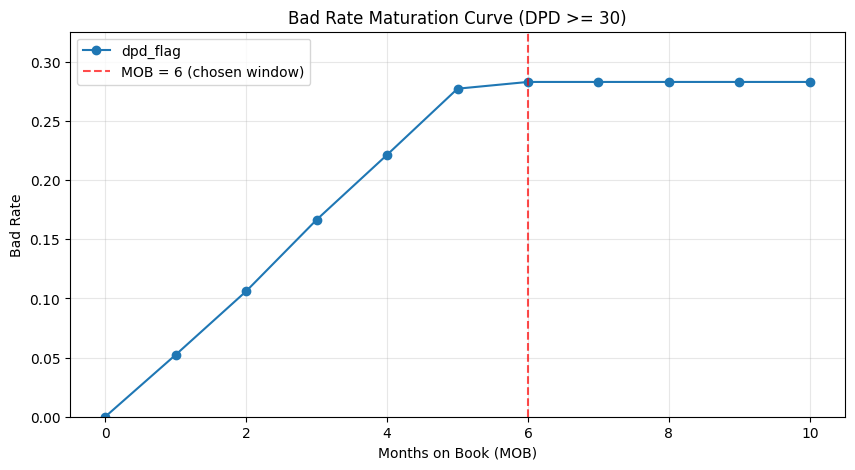

Bad rate at MOB 5: 0.2773
Bad rate at MOB 6: 0.2830
Bad rate at MOB 10: 0.2830


In [67]:
# Validate observation window: fix DPD at 30, check bad rate by MOB
dpd = 30

files_list = [silver_loan_directory + os.path.basename(f) for f in glob.glob(os.path.join(silver_loan_directory, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans to avoid right-censoring
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# visualise bad rate by MOB
pdf = df.toPandas()
grouped = pdf.groupby('mob')['dpd_flag'].mean()
grouped = grouped.sort_index()

grouped.plot(kind='line', marker='o', figsize=(10, 5))
plt.axvline(x=6, color='red', linestyle='--', alpha=0.7, label='MOB = 6 (chosen window)')
plt.title('Bad Rate Maturation Curve (DPD >= ' + str(dpd) + ')')
plt.xlabel('Months on Book (MOB)')
plt.ylabel('Bad Rate')
plt.ylim(0, grouped.max() * 1.15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Bad rate at MOB 5: {grouped[5]:.4f}")
print(f"Bad rate at MOB 6: {grouped[6]:.4f}")
print(f"Bad rate at MOB 10: {grouped[10]:.4f}")

There is still a small jump from MOB 5 to MOB 6 (roughly 0.8 percentage points). From MOB 6 to 10, the rate is flat. So the curve has not fully plateaued at MOB 5, it plateaus at MOB 6.

In [68]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

### Section 2 Summary: Label Definition Experiment

Tested 4 label combinations (DPD threshold x MOB window).

**Key findings:**
- All 4 combos produce nearly identical bad rates (~28.8%), indicating defaults in this portfolio are early-onset and severe (borrowers hit 60+ DPD within 6 months).
- Cohort stability is strong for 30dpd_6mob: std dev 2.33% across 25 monthly cohorts, range 24.6%-33.1%.
- 60dpd_6mob shows right-censoring in 2024-09 and 2024-10 (bad rate drops to 19.1%), making it less reliable.

**Design decision: 30dpd_6mob chosen** because: <br>
(1) 30 DPD is the industry-standard early default threshold,<br>
(2) 6-month window is the shortest that captures all defaults with no information loss, and <br> 
(3) stable across cohorts with no right-censoring risk.

## 3. Distributions

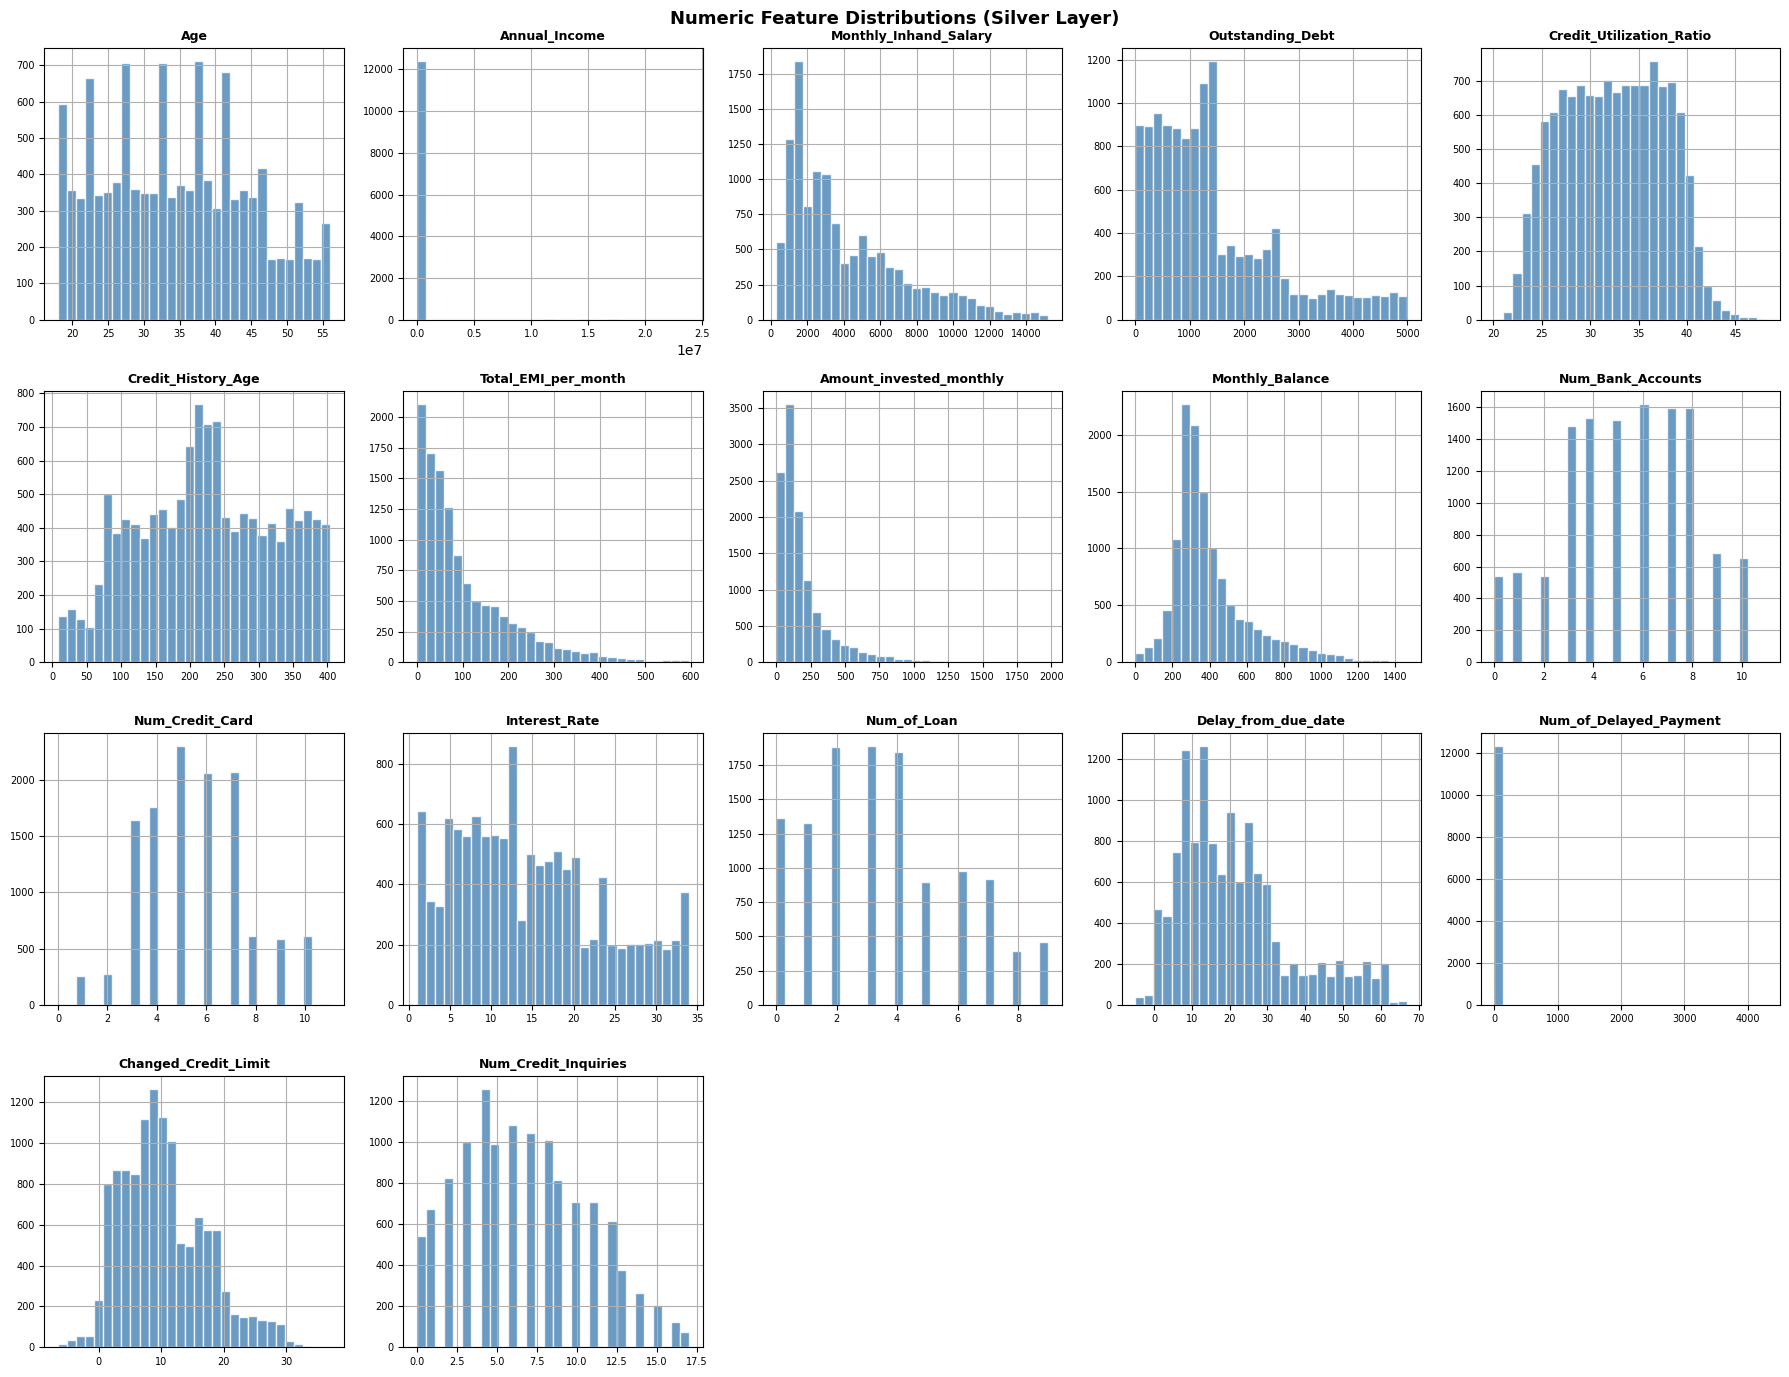

In [51]:
# Numeric feature distributions
df_features = df_attr.merge(df_fin, on=['Customer_ID', 'snapshot_date'], how='inner')

numeric_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries'
]

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

for i, col_name in enumerate(numeric_cols):
    ax = axes[i]
    df_features[col_name].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col_name, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions (Silver Layer)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

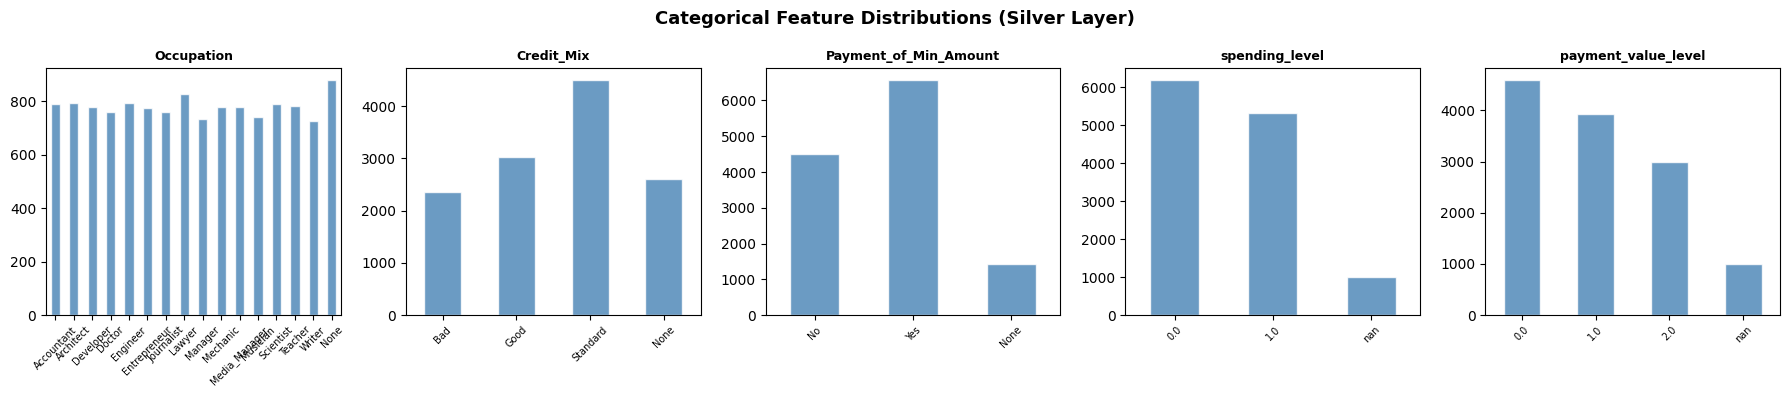

In [52]:
# Categorical feature distributions
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'spending_level', 'payment_value_level']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col_name in enumerate(cat_cols):
    ax = axes[i]
    counts = df_features[col_name].value_counts(dropna=False).sort_index()
    counts.plot.bar(ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col_name, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7, axis='x', rotation=45)
    ax.set_xlabel('')

plt.suptitle('Categorical Feature Distributions (Silver Layer)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [53]:
# Stats flag: skewness + near-zero variance
skew_df = df_features[numeric_cols].skew().round(2).rename('skewness')
nunique_df = df_features[cat_cols].nunique().rename('n_unique')

print("=== Numeric Skewness (|skew| > 2 = highly skewed) ===")
print(skew_df.sort_values(ascending=False).to_string())
print(f"\nHighly skewed features: {list(skew_df[skew_df.abs() > 2].index)}")

print("\n=== Categorical Unique Counts ===")
print(nunique_df.to_string())

dominant = {}
for c in cat_cols:
    top_pct = df_features[c].value_counts(normalize=True, dropna=False).iloc[0] * 100
    dominant[c] = round(top_pct, 1)
print(f"\nDominant category share: {dominant}")
print(f"Near-zero variance (>90% one category): {[k for k,v in dominant.items() if v > 90]}")

=== Numeric Skewness (|skew| > 2 = highly skewed) ===
Num_of_Delayed_Payment      13.28
Annual_Income               12.76
Amount_invested_monthly      2.58
Total_EMI_per_month          1.60
Monthly_Balance              1.55
Outstanding_Debt             1.21
Monthly_Inhand_Salary        1.13
Delay_from_due_date          0.97
Changed_Credit_Limit         0.63
Interest_Rate                0.49
Num_of_Loan                  0.45
Num_Credit_Inquiries         0.34
Num_Credit_Card              0.23
Age                          0.21
Credit_Utilization_Ratio     0.00
Credit_History_Age          -0.05
Num_Bank_Accounts           -0.19

Highly skewed features: ['Annual_Income', 'Amount_invested_monthly', 'Num_of_Delayed_Payment']

=== Categorical Unique Counts ===
Occupation               15
Credit_Mix                3
Payment_of_Min_Amount     2
spending_level            2
payment_value_level       3

Dominant category share: {'Occupation': np.float64(7.0), 'Credit_Mix': np.float64(36.0), 'Paymen

In [54]:
# Category size audit (5% threshold)
cat_audit = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'spending_level', 'payment_value_level']

# Also check discrete numeric features that might be treated as categorical
discrete_audit = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan', 'Interest_Rate', 'Num_Credit_Inquiries']

print("=== Categorical Features: % per group ===\n")
for c in cat_audit:
    pct = (df_features[c].value_counts(dropna=False, normalize=True) * 100).round(2)
    flags = pct[pct < 5]
    print(f"--- {c} ---")
    print(pct.to_string())
    if len(flags) > 0:
        print(f"  ** Groups below 5%: {dict(flags)}")
    print()

print("=== Discrete Numeric: % per value ===\n")
for c in discrete_audit:
    pct = (df_features[c].value_counts(dropna=False, normalize=True) * 100).round(2)
    flags = pct[pct < 5]
    print(f"--- {c} ({df_features[c].nunique()} unique values) ---")
    if len(flags) > 0:
        print(f"  Values below 5%: {dict(flags)}")
    else:
        print(f"  All groups >= 5%")
    print()

print("=== Age: binned into 10-year groups ===")
df_features['Age_bin'] = pd.cut(df_features['Age'], bins=[17, 25, 35, 45, 56], labels=['18-25', '26-35', '36-45', '46-56'])
pct = (df_features['Age_bin'].value_counts(dropna=False, normalize=True) * 100).round(2)
print(pct.to_string())
flags = pct[pct < 5]
if len(flags) > 0:
    print(f"  ** Groups below 5%: {dict(flags)}")
df_features.drop(columns=['Age_bin'], inplace=True)

=== Categorical Features: % per group ===

--- Occupation ---
Occupation
None             7.04
Lawyer           6.62
Architect        6.36
Engineer         6.34
Accountant       6.33
Scientist        6.31
Teacher          6.26
Developer        6.24
Media_Manager    6.24
Mechanic         6.24
Entrepreneur     6.21
Journalist       6.09
Doctor           6.08
Musician         5.93
Manager          5.89
Writer           5.82

--- Credit_Mix ---
Credit_Mix
Standard    35.98
Good        24.26
None        20.89
Bad         18.88

--- Payment_of_Min_Amount ---
Payment_of_Min_Amount
Yes     52.57
No      35.93
None    11.50

--- spending_level ---
spending_level
0.0    49.50
1.0    42.51
NaN     7.98

--- payment_value_level ---
payment_value_level
0.0    36.73
1.0    31.42
2.0    23.86
NaN     7.98

=== Discrete Numeric: % per value ===

--- Num_Bank_Accounts (12 unique values) ---
  Values below 5%: {1.0: np.float64(4.53), 2.0: np.float64(4.34), 0.0: np.float64(4.34), nan: np.float64(1.37), 1

### Section 3 Summary: Feature Distributions

**Numeric features (17 features):**
- Most features show reasonable spread with no unexpected spikes or gaps.
- 3 features are highly skewed (|skew| > 2): Annual_Income (12.76), Num_of_Delayed_Payment (13.28), Amount_invested_monthly (2.58). These are right-skewed with long tails, typical for financial data.
- Credit_Utilization_Ratio is nearly symmetric (skew 0.00), Age and Credit_History_Age are roughly uniform/symmetric.
- No transformation applied at this stage. Tree-based models are invariant to monotonic transforms, so skewness does not affect model performance.

**Categorical features (5 features):**
- Occupation: 15 categories, evenly distributed (~780 each), plus 7.0% null. No dominant category.
- Credit_Mix: 3 levels (Standard 36%, Good 24%, Bad 19%) + 20.9% null.
- Payment_of_Min_Amount: binary (Yes 52.6%, No 35.9%) + 11.5% null.
- spending_level: binary (0=49.5%, 1=42.5%) + 8.0% null.
- payment_value_level: 3 levels (0=36.7%, 1=31.4%, 2=23.9%) + 8.0% null.
- No near-zero variance features detected (no category exceeds 90% dominance).

**Category size audit (5% threshold for logistic regression):**
- All categorical feature groups are above 5%. No binning needed.
- Age binned into decade groups (18-25, 26-35, 36-45, 46-56): all above 5%. No binning needed.
- Discrete numeric features (Num_Bank_Accounts, Interest_Rate, etc.) have some values below 5%, but these will be fed as continuous numeric into both logistic regression and XGBoost, not one-hot encoded. The 5% rule does not apply to continuous inputs.

**Design decisions:**
- No feature transformations (log, binning, scaling) at this stage. Tree models handle skewness and varying scales natively. Features will be passed as-is to the gold layer.
- No category binning required. All categorical groups exceed the 5% minimum sample threshold needed for stable logistic regression coefficients.

## 4. Clickstream Missingness Analysis

In [55]:
# Customers with vs without clickstream data
click_customers = set(df_click['Customer_ID'].unique())
all_customers = set(df_attr['Customer_ID'].unique())

has_click = df_features[df_features['Customer_ID'].isin(click_customers)]
no_click = df_features[~df_features['Customer_ID'].isin(click_customers)]

print(f"Total customers: {len(all_customers)}")
print(f"With clickstream: {len(has_click)} ({len(has_click)/len(df_features)*100:.1f}%)")
print(f"Without clickstream: {len(no_click)} ({len(no_click)/len(df_features)*100:.1f}%)")

Total customers: 12500
With clickstream: 8974 (71.8%)
Without clickstream: 3526 (28.2%)


In [56]:
# Build label for comparison (30dpd_6mob chosen label)
files = glob.glob(os.path.join(silver_loan_directory, '*.parquet'))
df_silver_loan = spark.read.parquet(*files)

df_label = df_silver_loan.filter(col("mob") == 6) \
    .withColumn("label", F.when(col("dpd") >= 30, 1).otherwise(0)) \
    .select("Customer_ID", "label").toPandas()
df_label = df_label.drop_duplicates(subset=['Customer_ID'])

df_features_labeled = df_features.merge(df_label, on='Customer_ID', how='inner')
df_features_labeled['has_clickstream'] = df_features_labeled['Customer_ID'].isin(click_customers).astype(int)

print(f"Labeled dataset: {len(df_features_labeled)} rows")

Labeled dataset: 12500 rows


In [57]:
# Default rate comparison: with vs without clickstream
click_group = df_features_labeled.groupby('has_clickstream')['label'].agg(['mean', 'count']).reset_index()
click_group.columns = ['has_clickstream', 'bad_rate', 'count']
click_group['bad_rate_pct'] = (click_group['bad_rate'] * 100).round(2)
click_group['has_clickstream'] = click_group['has_clickstream'].map({0: 'No clickstream', 1: 'Has clickstream'})
print(click_group[['has_clickstream', 'count', 'bad_rate_pct']].to_string(index=False))

has_clickstream  count  bad_rate_pct
 No clickstream   3526         28.67
Has clickstream   8974         28.87


In [58]:
# Chi-square test: is the default rate difference statistically significant?
from scipy.stats import chi2_contingency

ct = pd.crosstab(df_features_labeled['has_clickstream'], df_features_labeled['label'])
chi2, p_value, dof, expected = chi2_contingency(ct)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
if p_value < 0.05:
    print("Result: Statistically significant difference in default rate between groups.")
else:
    print("Result: No significant difference. Missingness appears random (MAR/MCAR).")

Chi-square statistic: 0.0399
p-value: 0.8417
Degrees of freedom: 1
Result: No significant difference. Missingness appears random (MAR/MCAR).


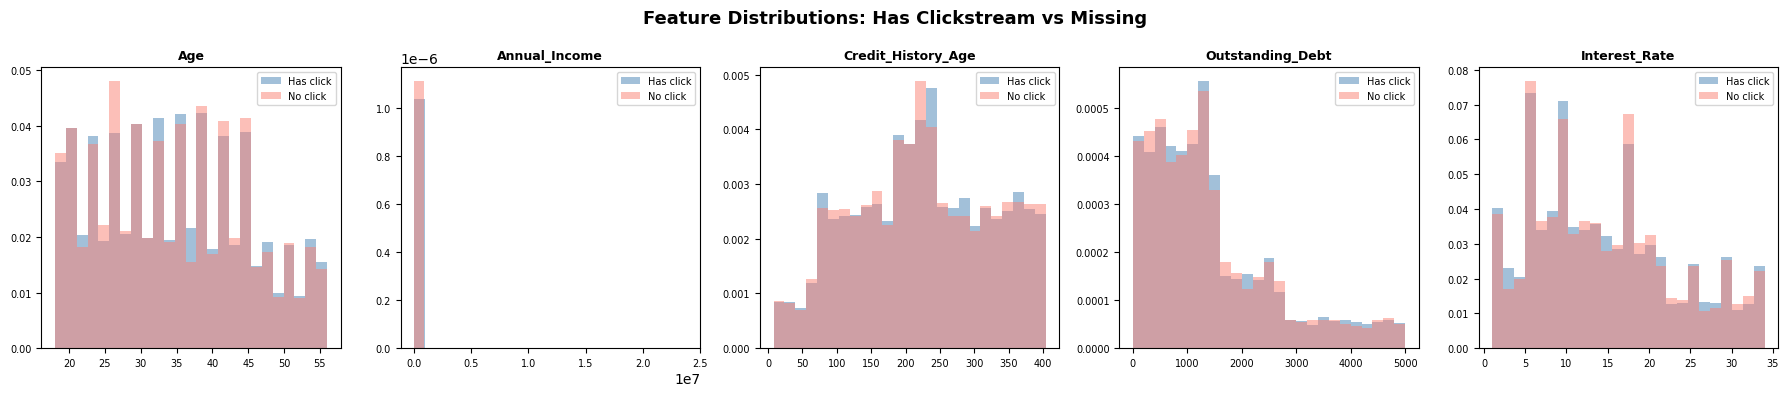

In [59]:
# Feature distribution comparison: missing vs present clickstream
compare_cols = ['Age', 'Annual_Income', 'Credit_History_Age', 'Outstanding_Debt', 'Interest_Rate']

fig, axes = plt.subplots(1, len(compare_cols), figsize=(18, 4))

for i, col_name in enumerate(compare_cols):
    ax = axes[i]
    has_click_vals = df_features_labeled.loc[df_features_labeled['has_clickstream'] == 1, col_name].dropna()
    no_click_vals = df_features_labeled.loc[df_features_labeled['has_clickstream'] == 0, col_name].dropna()
    ax.hist(has_click_vals, bins=25, alpha=0.5, color='steelblue', label='Has click', density=True)
    ax.hist(no_click_vals, bins=25, alpha=0.5, color='salmon', label='No click', density=True)
    ax.set_title(col_name, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions: Has Clickstream vs Missing', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Section 4 Summary: Clickstream Missingness Analysis

28.2% of customers (3,526 of 12,500) have no clickstream data.

**Chi-square test (p=0.84):** The default rate is nearly identical between customers with clickstream (28.87%) and without (28.67%). A significant result would have meant that some hidden factor links clickstream availability to default risk, which would make the missingness itself a predictor and require careful handling (missing indicator flags, separate modeling, or investigation into the root cause). Because the result is not significant, we know the gap is just random. This justifies a simple left join without worrying that the 28% missing group introduces bias into the model.

**Feature distribution comparison:** Age, Annual_Income, Credit_History_Age, Outstanding_Debt, and Interest_Rate all show near-identical shapes between the two groups. This rules out a subtler problem that chi-square alone could miss: even if default rates were similar, the two groups could have different feature profiles (e.g., missing clickstream customers skewing younger or lower income), which would mean the model learns different patterns from each group. Because the distributions overlap, we know the two groups are drawn from the same population, and mixing them in one training set will not confuse the model.

**Design decisions:**
- Left join at gold layer is safe because both the outcome (default rate) and the inputs (feature distributions) are indistinguishable between the two groups. Excluding 3,526 customers would waste 28% of training data without reducing any bias.
- Fill missing clickstream features with NaN because the gap carries no hidden signal. Imputing would add artificial values to a group that already behaves identically to the rest.
- Add a `has_clickstream` binary flag as a low-cost safeguard. Since missingness is random, we do not expect it to be predictive, but including it lets the model confirm that rather than us assuming it.

## 5. Bivariate Analysis

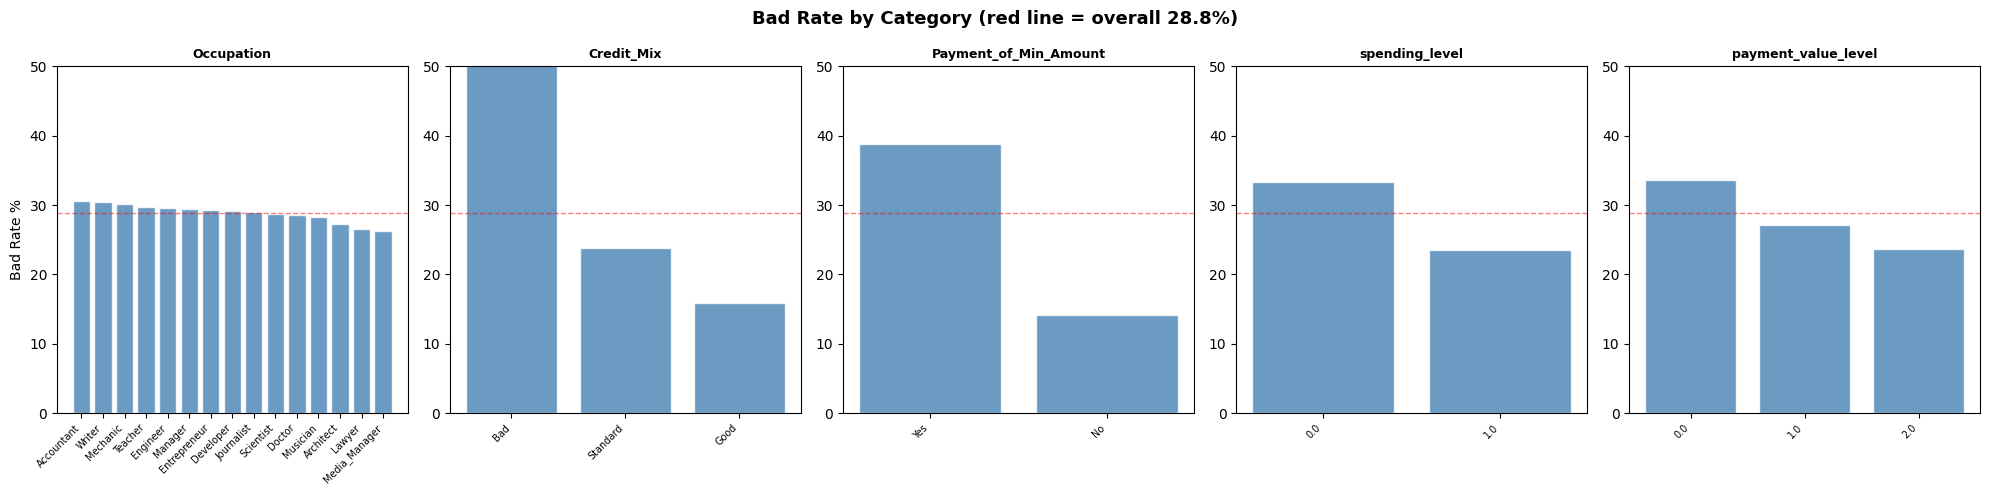

In [60]:
# Categorical features: bad rate by category
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'spending_level', 'payment_value_level']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col_name in enumerate(cat_cols):
    ax = axes[i]
    group = df_features_labeled.groupby(col_name)['label'].agg(['mean', 'count']).reset_index()
    group['bad_rate_pct'] = (group['mean'] * 100).round(2)
    group = group.sort_values('bad_rate_pct', ascending=False)
    
    bars = ax.bar(range(len(group)), group['bad_rate_pct'], color='steelblue', edgecolor='white', alpha=0.8)
    ax.axhline(y=28.82, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title(col_name, fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(group)))
    ax.set_xticklabels(group[col_name].astype(str), rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Bad Rate %' if i == 0 else '')
    ax.set_ylim(0, 50)

plt.suptitle('Bad Rate by Category (red line = overall 28.8%)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Credit_Mix is the standout. "Bad" credit mix has a 50% default rate compared to 16% for "Good" credit mix. That is a 3x difference, which is why it ranks 2nd overall. Payment_of_Min_Amount shows "Yes" (pays minimum) at 39% default vs "No" at 14%. Paying only the minimum is a risk signal, which is intuitive.

Occupation is flat: all 15 occupations hover between 26-31%, barely deviating from the overall 28.8% line. This confirms the p=0.82 result. Occupation has no predictive power for default in this dataset.

In [61]:
# Separation check: flag categories with extreme bad rates
print("=== Complete / Quasi-Complete Separation Check ===\n")
for col_name in cat_cols:
    group = df_features_labeled.groupby(col_name)['label'].agg(['mean', 'count']).reset_index()
    group['bad_rate_pct'] = (group['mean'] * 100).round(2)
    
    complete = group[(group['bad_rate_pct'] == 0) | (group['bad_rate_pct'] == 100)]
    quasi = group[((group['bad_rate_pct'] > 0) & (group['bad_rate_pct'] < 2)) | 
                  ((group['bad_rate_pct'] > 98) & (group['bad_rate_pct'] < 100))]
    
    if len(complete) > 0:
        print(f"  {col_name}: COMPLETE separation in {list(complete[col_name])}")
    elif len(quasi) > 0:
        print(f"  {col_name}: QUASI-COMPLETE separation in {list(quasi[col_name])}")
    else:
        print(f"  {col_name}: No separation issues (range {group['bad_rate_pct'].min():.1f}% - {group['bad_rate_pct'].max():.1f}%)")

=== Complete / Quasi-Complete Separation Check ===

  Occupation: No separation issues (range 26.3% - 30.6%)
  Credit_Mix: No separation issues (range 15.9% - 56.1%)
  Payment_of_Min_Amount: No separation issues (range 14.1% - 38.8%)
  spending_level: No separation issues (range 23.5% - 33.4%)
  payment_value_level: No separation issues (range 23.7% - 33.6%)


No complete or quasi-complete separation found. Good to run logistic regression. 

C:\Users\Hello\AppData\Local\Temp\ipykernel_11768\2076383776.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_good, data_bad], labels=['Good', 'Bad'], widths=0.6,
C:\Users\Hello\AppData\Local\Temp\ipykernel_11768\2076383776.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_good, data_bad], labels=['Good', 'Bad'], widths=0.6,
C:\Users\Hello\AppData\Local\Temp\ipykernel_11768\2076383776.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_good, data_bad], labels=['Good', 'Bad'], widths=0.6,
C:\Users\Hello\AppData\Local\Temp\ipykernel_11768\2076383776.py:18: Matpl

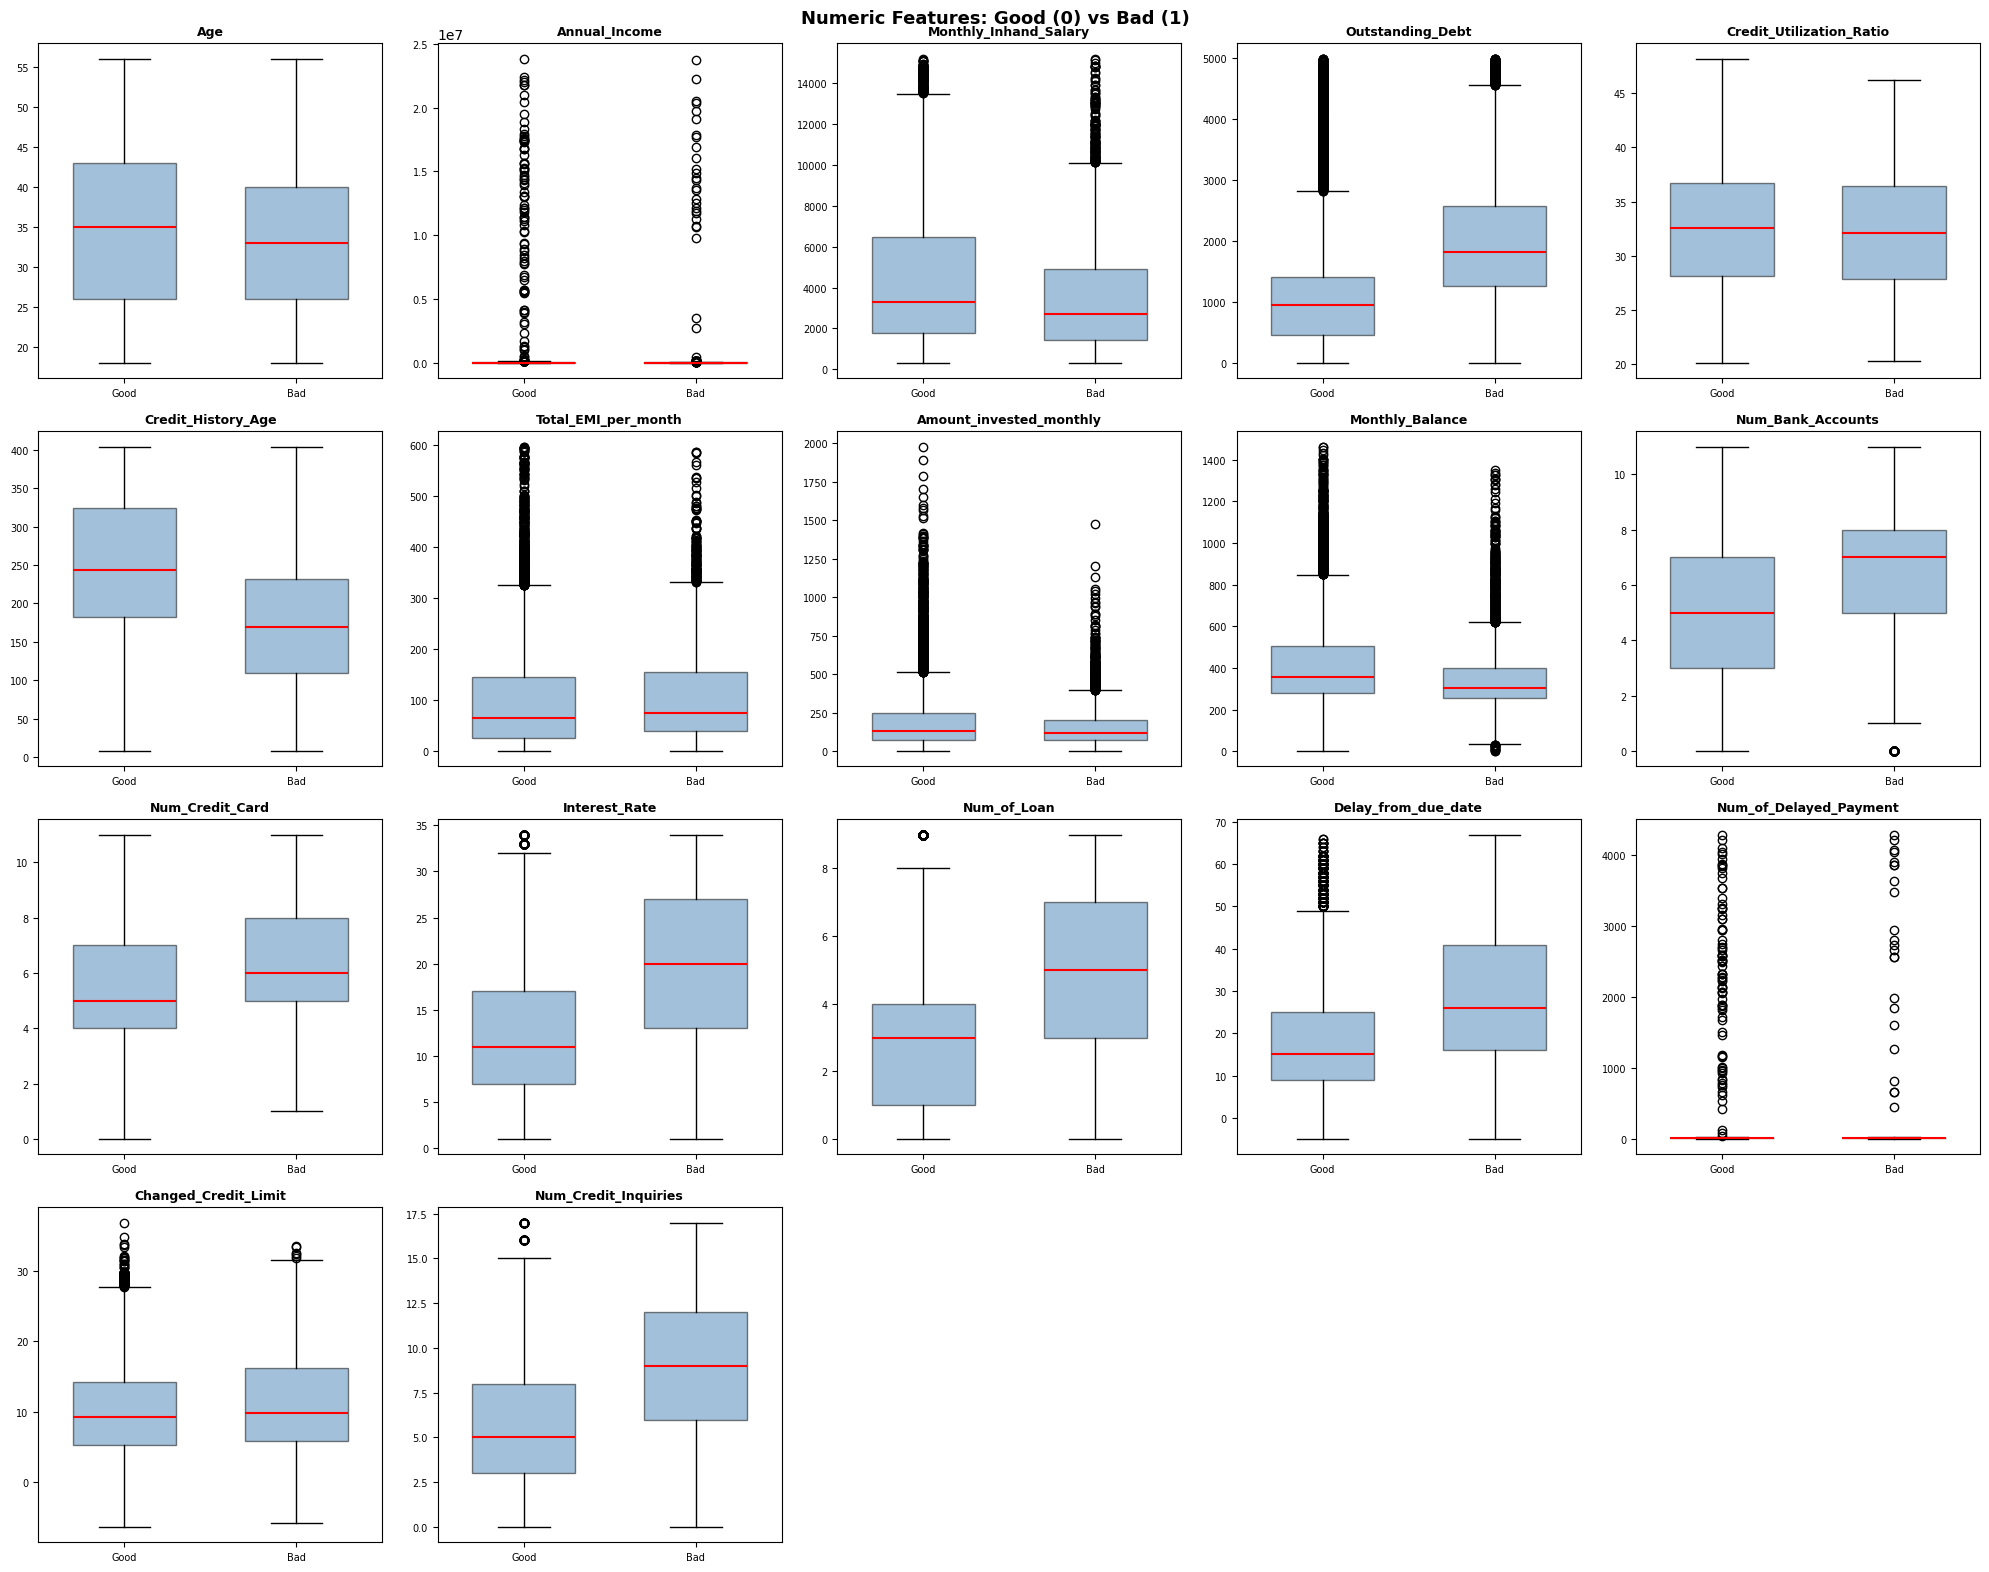

In [62]:
# Numeric features: boxplots by label (good vs bad)
numeric_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries'
]

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col_name in enumerate(numeric_cols):
    ax = axes[i]
    data_good = df_features_labeled.loc[df_features_labeled['label'] == 0, col_name].dropna()
    data_bad = df_features_labeled.loc[df_features_labeled['label'] == 1, col_name].dropna()
    ax.boxplot([data_good, data_bad], labels=['Good', 'Bad'], widths=0.6,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='red', linewidth=1.5))
    ax.set_title(col_name, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features: Good (0) vs Bad (1)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [63]:
# Feature association ranking: point-biserial correlation (numeric) + Cramer's V (categorical)
from scipy.stats import pointbiserialr

rankings = []

for col_name in numeric_cols:
    valid = df_features_labeled[[col_name, 'label']].dropna()
    if len(valid) > 0:
        corr, p = pointbiserialr(valid['label'], valid[col_name])
        rankings.append({'feature': col_name, 'type': 'numeric', 'association': abs(round(corr, 4)), 'p_value': round(p, 6), 'direction': 'higher in bad' if corr > 0 else 'higher in good'})

for col_name in cat_cols:
    ct = pd.crosstab(df_features_labeled[col_name], df_features_labeled['label'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    rankings.append({'feature': col_name, 'type': 'categorical', 'association': round(cramers_v, 4), 'p_value': round(p, 6), 'direction': 'varies by group'})

rank_df = pd.DataFrame(rankings).sort_values('association', ascending=False)
print(rank_df.to_string(index=False))

                 feature        type  association  p_value       direction
           Interest_Rate     numeric       0.3620 0.000000   higher in bad
              Credit_Mix categorical       0.3418 0.000000 varies by group
    Num_Credit_Inquiries     numeric       0.3299 0.000000   higher in bad
     Delay_from_due_date     numeric       0.3198 0.000000   higher in bad
        Outstanding_Debt     numeric       0.3169 0.000000   higher in bad
         Num_Credit_Card     numeric       0.2966 0.000000   higher in bad
      Credit_History_Age     numeric       0.2919 0.000000  higher in good
             Num_of_Loan     numeric       0.2778 0.000000   higher in bad
   Payment_of_Min_Amount categorical       0.2677 0.000000 varies by group
       Num_Bank_Accounts     numeric       0.2560 0.000000   higher in bad
         Monthly_Balance     numeric       0.1475 0.000000  higher in good
   Monthly_Inhand_Salary     numeric       0.1461 0.000000  higher in good
          spending_level 

The direction column is important. "Higher in bad" means defaulters tend to have higher values (e.g., higher Interest_Rate, more credit inquiries, more debt). "Higher in good" means non-defaulters have higher values (e.g., longer Credit_History_Age, higher Monthly_Balance). This makes business sense: risky borrowers carry more debt, have shorter credit histories, and get charged higher interest rates.

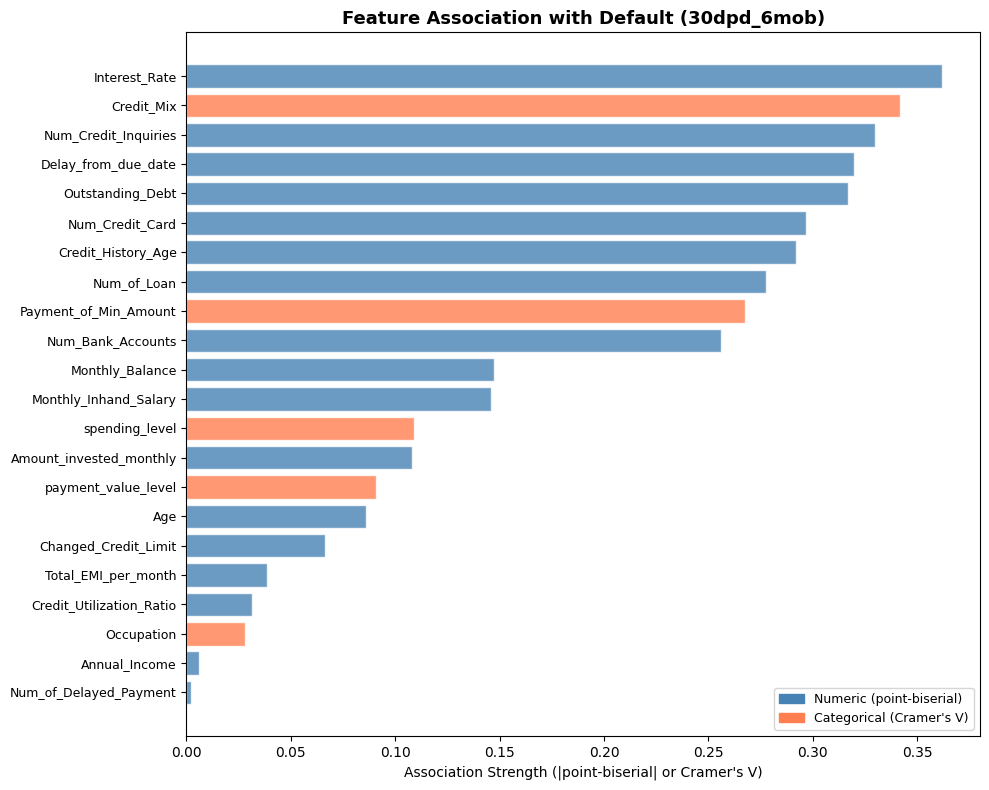

In [64]:
# Ranked association chart
rank_df_sorted = rank_df.sort_values('association', ascending=True)
colors = ['steelblue' if t == 'numeric' else 'coral' for t in rank_df_sorted['type']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(rank_df_sorted)), rank_df_sorted['association'], color=colors, edgecolor='white', alpha=0.8)
ax.set_yticks(range(len(rank_df_sorted)))
ax.set_yticklabels(rank_df_sorted['feature'], fontsize=9)
ax.set_xlabel('Association Strength (|point-biserial| or Cramer\'s V)')
ax.set_title('Feature Association with Default (30dpd_6mob)', fontweight='bold', fontsize=13)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Numeric (point-biserial)'),
                   Patch(color='coral', label='Categorical (Cramer\'s V)')],
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

This answers: "which features have the strongest linear relationship with default?" Point-biserial correlation measures how much a numeric feature's values differ between good and bad customers. Cramer's V does the same for categorical features. Both give a number between 0 (no relationship) and 1 (perfect relationship).

### Section 5 Summary: Bivariate Analysis

Features ranked by association strength with default label (30dpd_6mob) using point-biserial correlation for numeric features and Cramer's V for categorical features.

**Top predictors (association > 0.25):**
Interest_Rate (0.36), Credit_Mix (0.34), Num_Credit_Inquiries (0.33), Delay_from_due_date (0.32), Outstanding_Debt (0.32), Num_Credit_Card (0.30), Credit_History_Age (0.29), Num_of_Loan (0.28), Payment_of_Min_Amount (0.27), Num_Bank_Accounts (0.26). These form the core predictive feature set. Directions are business-intuitive: defaulters carry more debt, higher interest rates, more credit products, and shorter credit histories.

**Moderate predictors (0.08-0.15):**
Monthly_Balance (0.15), Monthly_Inhand_Salary (0.15), spending_level (0.11), Amount_invested_monthly (0.11), payment_value_level (0.09), Age (0.09). These contribute secondary signal and are worth retaining.

**Weak/non-significant predictors (<0.07):**
Changed_Credit_Limit (0.07), Total_EMI_per_month (0.04), Credit_Utilization_Ratio (0.03), Occupation (0.03, p=0.82), Annual_Income (0.01, p=0.52), Num_of_Delayed_Payment (0.00, p=0.81). Occupation, Annual_Income, and Num_of_Delayed_Payment show no statistically significant relationship with default. Num_of_Delayed_Payment's lack of signal is likely because Delay_from_due_date already captures the same information more effectively.

**Separation check (logistic regression safety):**
No complete or quasi-complete separation detected in any categorical feature. The widest bad rate spread is Credit_Mix (15.9% for "Good" to 56.1% for "Bad"), which is strong discriminative power but well within safe bounds for coefficient estimation. Logistic regression will converge without regularization workarounds.

**Design decisions:**
- Keep all 22 features in the gold layer rather than dropping the weak ones. Point-biserial and Cramer's V only measure linear/marginal association. XGBoost can capture non-linear interactions that these tests miss, so a weak marginal signal does not mean a feature is useless in a tree ensemble. Dropping features based on univariate tests risks losing interaction effects.
- For logistic regression, the ranking informs which features to focus on during interpretation (top 10 carry most of the signal), but pre-filtering is unnecessary since regularization (L1/L2) will shrink weak coefficients toward zero automatically.
- No separation remediation needed. All categorical groups have bad rates between 14% and 56%, so logistic regression coefficients will be stable without special handling.

## 6. Correlation Matrix

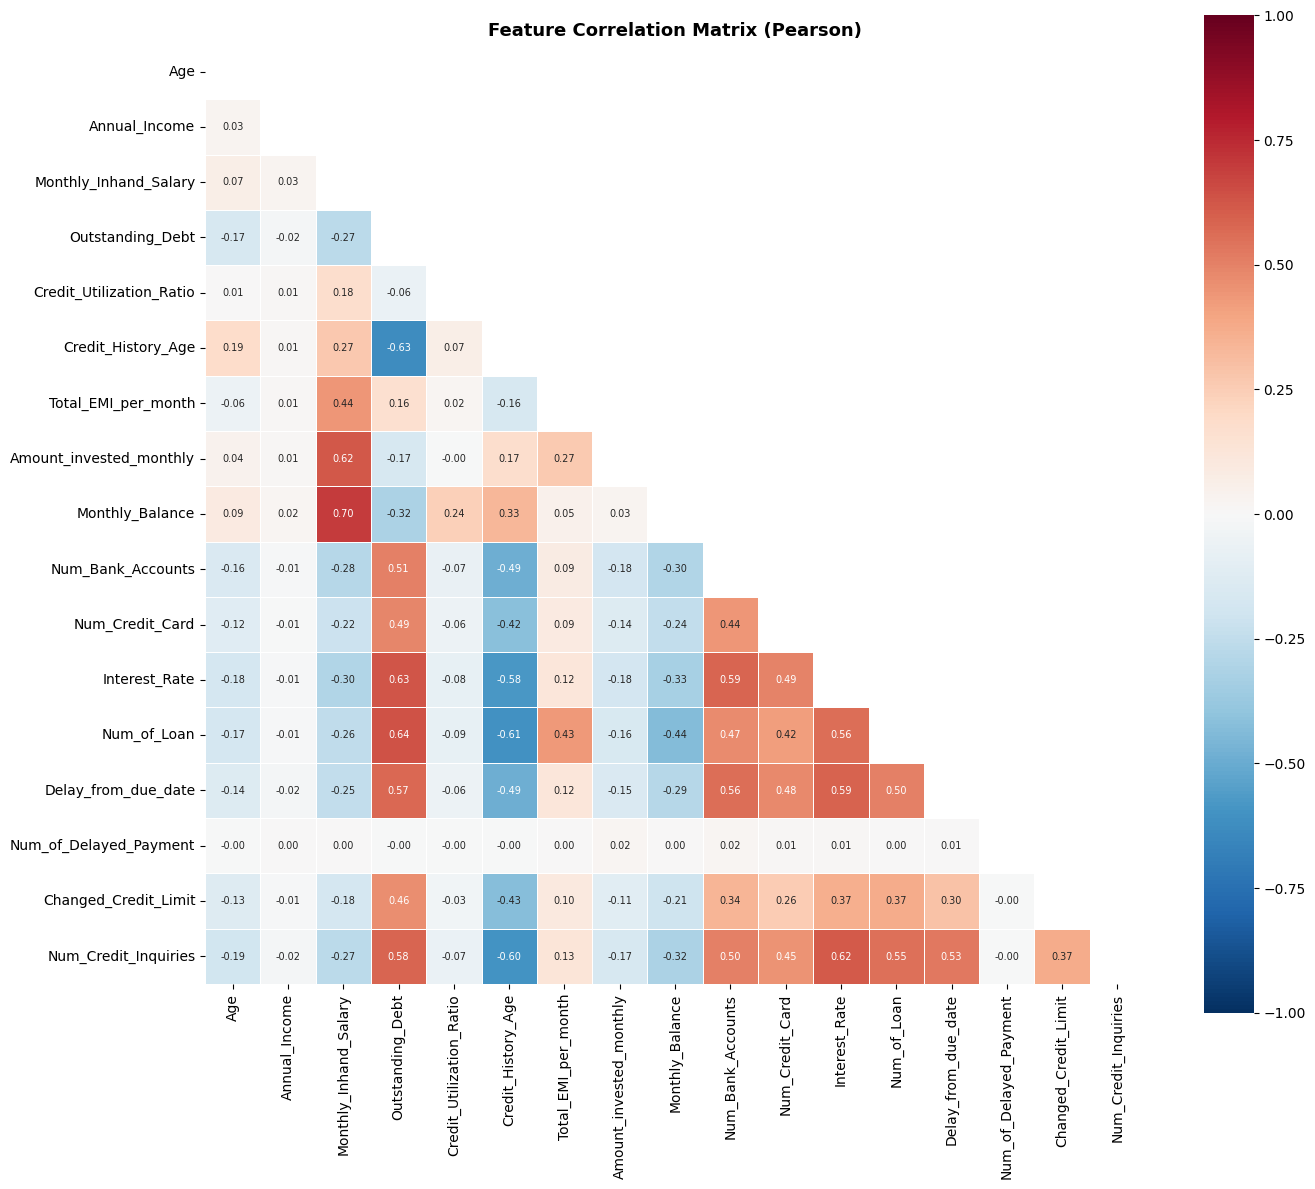

In [65]:
# Correlation heatmap for numeric features
numeric_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries'
]

corr = df_features[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Matrix (Pearson)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [66]:
# Flag highly correlated pairs (|r| > 0.7)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({
                'feature_1': corr.columns[i],
                'feature_2': corr.columns[j],
                'correlation': round(r, 3)
            })

if len(high_corr) > 0:
    print("=== Highly Correlated Pairs (|r| > 0.7) ===")
    hc_df = pd.DataFrame(high_corr).sort_values('correlation', key=abs, ascending=False)
    print(hc_df.to_string(index=False))
else:
    print("No feature pairs with |r| > 0.7 found.")

# Also show moderate correlations for awareness
moderate_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if 0.5 < abs(r) <= 0.7:
            moderate_corr.append({
                'feature_1': corr.columns[i],
                'feature_2': corr.columns[j],
                'correlation': round(r, 3)
            })

if len(moderate_corr) > 0:
    print(f"\n=== Moderately Correlated Pairs (0.5 < |r| <= 0.7) ===")
    mc_df = pd.DataFrame(moderate_corr).sort_values('correlation', key=abs, ascending=False)
    print(mc_df.to_string(index=False))

=== Highly Correlated Pairs (|r| > 0.7) ===
            feature_1       feature_2  correlation
Monthly_Inhand_Salary Monthly_Balance        0.701

=== Moderately Correlated Pairs (0.5 < |r| <= 0.7) ===
            feature_1               feature_2  correlation
     Outstanding_Debt             Num_of_Loan        0.640
     Outstanding_Debt           Interest_Rate        0.630
     Outstanding_Debt      Credit_History_Age       -0.629
Monthly_Inhand_Salary Amount_invested_monthly        0.620
        Interest_Rate    Num_Credit_Inquiries        0.616
   Credit_History_Age             Num_of_Loan       -0.606
   Credit_History_Age    Num_Credit_Inquiries       -0.598
        Interest_Rate     Delay_from_due_date        0.588
    Num_Bank_Accounts           Interest_Rate        0.586
     Outstanding_Debt    Num_Credit_Inquiries        0.583
   Credit_History_Age           Interest_Rate       -0.579
     Outstanding_Debt     Delay_from_due_date        0.571
        Interest_Rate          

### Section 6 Summary: Correlation Matrix

**High correlation (|r| > 0.7):**
One pair found: Monthly_Inhand_Salary and Monthly_Balance (r=0.70). This is borderline and expected since higher earners tend to carry higher balances.

**Design decisions:**
- Keep all features. The highest correlation (0.70) is not severe enough to force a drop, and tree models are unaffected by multicollinearity. For logistic regression in Assignment 2, L1/L2 regularization will shrink redundant coefficients and stabilize estimation without requiring manual feature removal.

## 7. Feature Selection Summary for Gold Layer

### Section 7 Summary: Feature Selection for Gold Layer

Total features: 23 structured + 20 clickstream = 43 features.

**From Attributes (2 features):**
- Age (numeric, association 0.09, null 7.9%): Moderate signal, no issues.
- Occupation (categorical, association 0.03, null 7.0%): Weak marginal signal but low cost to keep. Let model decide its usefulness through regularization or tree splits.

**From Financials (20 features):**
- **Strong predictors (association > 0.25):** Interest_Rate (0.36), Credit_Mix (0.34), Num_Credit_Inquiries (0.33), Delay_from_due_date (0.32), Outstanding_Debt (0.32), Num_Credit_Card (0.30), Credit_History_Age (0.29), Num_of_Loan (0.28), Payment_of_Min_Amount (0.27), Num_Bank_Accounts (0.26). These form the core of the model.
- **Moderate predictors (0.08-0.15):** Monthly_Balance (0.15), Monthly_Inhand_Salary (0.15), spending_level (0.11), Amount_invested_monthly (0.11), payment_value_level (0.09).
- **Weak predictors (<0.07):** Changed_Credit_Limit (0.07), Total_EMI_per_month (0.04), Credit_Utilization_Ratio (0.03), Annual_Income (0.01), Num_of_Delayed_Payment (0.00). Kept because univariate weakness does not imply uselessness in a multivariate model. Tree models can discover interaction effects that marginal tests miss, and regularization will shrink truly useless coefficients in logistic regression.

**Derived (1 feature):**
- has_clickstream (binary, null 0%): Flags whether the customer has clickstream data. Missingness is confirmed random (chi-square p=0.84), so the flag is a low-cost safeguard rather than an expected predictor.

**Clickstream (20 features):**
- fe_1 to fe_20 included via left join on Customer_ID. Missing customers (28.2%) filled with NaN. These are anonymous pre-processed features with no domain interpretation available.

**Design rationale:**
- No features dropped. The cost of including a weak feature is minimal (slight increase in training time), while the cost of dropping a useful one is lost predictive power that cannot be recovered. Regularization and tree pruning handle redundancy automatically.
- No imputation at gold layer. NaN preserved for XGBoost native handling. Imputation strategy deferred to Assignment 2 model pipelines where it can differ per model (NaN for XGBoost, median/mode imputation for logistic regression).
- Left join ensures all 12,500 customers are retained regardless of clickstream availability, justified by the MCAR finding in Section 4.